## اختبار تأثير تجميع المستندات (Document Clustering)

هذا الـ Notebook ليس لتقييم MAP، بل لإظهار **كيف يمكننا الاستفادة من نتائج التجميع بشكل عملي** لتحسين تجربة المستخدم.

**الفكرة:** بعد إجراء بحث عادي، سنقوم بجلب النتائج الأعلى، ثم لكل نتيجة، سنعرض **5 مستندات أخرى من نفس العنقود (Cluster)**. هذا يعادل ميزة "مستندات أخرى قد تهمك" أو "تصفح هذا الموضوع".

### الخطوة 1: الإعداد وتحميل الملفات اللازمة

In [1]:
import requests
import pandas as pd
import joblib
import sys
import os
import random

project_root = os.path.dirname(os.path.abspath(os.getcwd()))
sys.path.append(project_root)
from config import API_PORTS, MODELS_DIR

# --- الإعدادات ---
DATASET_NAME = 'beir/quora'
SEARCH_API_URL = f"http://127.0.0.1:{API_PORTS['SEARCH']}/search/"
MODEL_DIR = os.path.join(project_root, MODELS_DIR, DATASET_NAME.replace('/', '_'))

try:
    print("Loading required model files...")
    doc_ids = joblib.load(os.path.join(MODEL_DIR, 'doc_ids.joblib'))
    clusters = joblib.load(os.path.join(MODEL_DIR, 'clusters.joblib'))
    
    # إنشاء بنية بيانات فعالة للبحث عن المستندات في كل عنقود
    cluster_to_docs = {}
    for doc_id, cluster_id in zip(doc_ids, clusters):
        if cluster_id not in cluster_to_docs:
            cluster_to_docs[cluster_id] = []
        cluster_to_docs[cluster_id].append(doc_id)
        
    print("Files loaded and cluster map created successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure you have run the representation and clustering processes for '{DATASET_NAME}'.")

Loading required model files...
Files loaded and cluster map created successfully.


### الخطوة 2 (أ): تبرير اختيار عدد العناقيد (Elbow Method)

قبل استخدام نتائج التجميع، من المهم تبرير لماذا اخترنا عددًا معينًا من العناقيد (clusters). إحدى الطرق الشائعة هي **"طريقة الكوع" (Elbow Method)**.

**الفكرة:** نقوم بتشغيل خوارزمية التجميع (مثل K-Means) عدة مرات مع عدد مختلف من العناقيد (k)، وفي كل مرة نحسب مجموع مربع المسافات داخل كل عنقود (Sum of Squared Errors - SSE). بعدها، نرسم مخططًا بيانيًا يوضح العلاقة بين `k` و `SSE`. النقطة التي يبدأ عندها المخطط بالاستواء وتشبه "كوع" الذراع هي غالبًا أفضل قيمة لـ `k`.

**ملاحظة:** الخلية التالية تحتوي على الكود اللازم لإنشاء هذا المخطط. لكنها **للتوضيح فقط** ولا يمكن تشغيلها مباشرة، لأنها تتطلب مصفوفة المتجهات الرقمية للمستندات (`X_represented`) والتي لم يتم تحميلها في هذا الـ Notebook.

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# NOTE: This cell is for demonstration purposes and cannot be run directly.
# It requires the document representations (vectors), which are not loaded in this notebook.
# To run it, you must first load the document vectors used for clustering,
# for example: X_represented = joblib.load(os.path.join(MODEL_DIR, 'vectors.joblib'))

def plot_elbow_method(X_represented):
    """Calculates SSE for a range of k and plots the elbow curve."""
    sse = []
    k_range = range(2, 16) # Test k from 2 to 15
    print("Calculating SSE for a range of k values...")
    for k in k_range:
        print(f"Running K-Means for k={k}...")
        # Use n_init='auto' to avoid FutureWarning
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', verbose=0)
        kmeans.fit(X_represented)
        sse.append(kmeans.inertia_) # .inertia_ is the SSE value
    
    # Plotting the elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, sse, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.title('Elbow Method for Optimal k')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()

# --- Example Usage (do not run without vectors) ---
# if 'X_represented' in locals():
#     plot_elbow_method(X_represented)
# else:
#     print("Could not run elbow plot: Document vectors 'X_represented' not loaded.")

print("The code in this cell is a template for generating an elbow plot.")
print("To use it, load your document vectors and call the plot_elbow_method function.")
print("Look for the 'elbow' point on the graph where the rate of decrease in SSE slows down significantly.")
print("This point suggests the optimal number of clusters for your data.")

The code in this cell is a template for generating an elbow plot.
To use it, load your document vectors and call the plot_elbow_method function.
Look for the 'elbow' point on the graph where the rate of decrease in SSE slows down significantly.
This point suggests the optimal number of clusters for your data.


### الخطوة 2 (ب): تحليل توزيع المستندات على العناقيد

من المفيد أيضًا تحليل كيفية توزيع المستندات على العناقيد التي تم إنشاؤها. هذا يساعدنا على فهم ما إذا كانت العناقيد متوازنة أم أن هناك عناقيد كبيرة جدًا أو صغيرة جدًا. الرسم البياني التالي يوضح عدد المستندات في كل عنقود.

/tmp/ipykernel_16432/2162280314.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


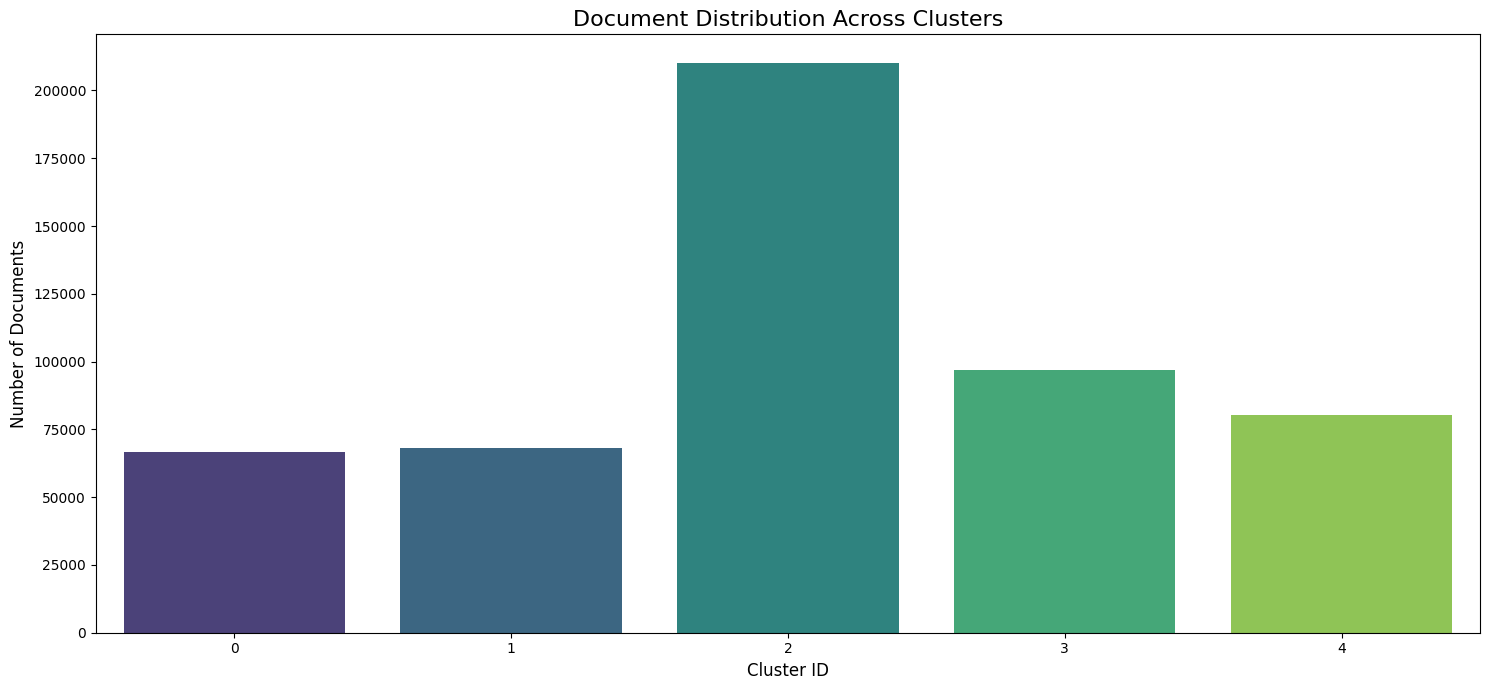


--- Cluster Statistics ---
Total number of documents: 522583
Total number of clusters: 5
Average documents per cluster: 104516.60
Largest cluster (ID 2) has 210200 documents.
Smallest cluster (ID 0) has 66837 documents.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# This code assumes 'clusters' variable is loaded from the first code cell

def plot_cluster_distribution(clusters):
    """Creates and displays a bar chart of document distribution across clusters."""
    if not isinstance(clusters, pd.Series):
        cluster_series = pd.Series(clusters)
    
    cluster_counts = cluster_series.value_counts().sort_index()

    plt.figure(figsize=(15, 7))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
    plt.title('Document Distribution Across Clusters', fontsize=16)
    plt.xlabel('Cluster ID', fontsize=12)
    plt.ylabel('Number of Documents', fontsize=12)
    if len(cluster_counts) > 20: # Rotate labels only if there are many clusters
        plt.xticks(rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Cluster Statistics ---")
    print(f"Total number of documents: {len(clusters)}")
    print(f"Total number of clusters: {len(cluster_counts)}")
    print(f"Average documents per cluster: {cluster_counts.mean():.2f}")
    print(f"Largest cluster (ID {cluster_counts.idxmax()}) has {cluster_counts.max()} documents.")
    print(f"Smallest cluster (ID {cluster_counts.idxmin()}) has {cluster_counts.min()} documents.")

# --- Plotting the distribution ---
if 'clusters' in locals():
    plot_cluster_distribution(clusters)
else:
    print("Could not plot distribution: 'clusters' data not loaded.")

### الخطوة 3: إجراء بحث وعرض النتائج مع "مستندات ذات صلة"

In [4]:
def search_and_find_related(query, model='hybrid'):
    print(f"--- Searching for: '{query}' ---\n")
    
    # 1. إجراء البحث العادي
    payload = {"dataset_name": DATASET_NAME, "query": query, "model_type": model}
    response = requests.post(SEARCH_API_URL, json=payload)
    top_results = response.json().get('results', [])
    
    if not top_results:
        print("No results found.")
        return
    
    # 2. لكل نتيجة، جلب مستندات أخرى من نفس العنقود
    for i, result in enumerate(top_results[:3]): # نعرض أول 3 نتائج فقط للتوضيح
        doc_id = result['doc_id']
        score = result['score']
        
        # إيجاد العنقود الذي ينتمي إليه هذا المستند
        doc_index = doc_ids.index(doc_id)
        cluster_id = clusters[doc_index]
        
        # جلب مستندات أخرى من نفس العنقود
        related_docs = cluster_to_docs.get(cluster_id, [])
        # إزالة المستند نفسه من قائمة المستندات ذات الصلة
        related_docs = [d for d in related_docs if d != doc_id]
        # أخذ عينة عشوائية
        sample_related = random.sample(related_docs, min(len(related_docs), 5))
        
        print(f"\n===================================================")
        print(f"Result #{i+1} | Doc ID: {doc_id} | Score: {score:.4f} | Cluster: {cluster_id}")
        print(f"---------------------------------------------------")
        print(f"-> Other documents in the same topic cluster:")
        for related_id in sample_related:
            print(f"   - Doc ID: {related_id}")
        print(f"===================================================")

# --- تجربة عملية ---
test_query = "what is the best way to learn python?"
search_and_find_related(test_query)

--- Searching for: 'what is the best way to learn python?' ---


Result #1 | Doc ID: 32797 | Score: 1.0000 | Cluster: 4
---------------------------------------------------
-> Other documents in the same topic cluster:
   - Doc ID: 73312
   - Doc ID: 284242
   - Doc ID: 102522
   - Doc ID: 65653
   - Doc ID: 468269

Result #2 | Doc ID: 35961 | Score: 0.9530 | Cluster: 4
---------------------------------------------------
-> Other documents in the same topic cluster:
   - Doc ID: 331945
   - Doc ID: 372350
   - Doc ID: 36122
   - Doc ID: 406457
   - Doc ID: 395525

Result #3 | Doc ID: 13142 | Score: 0.8470 | Cluster: 4
---------------------------------------------------
-> Other documents in the same topic cluster:
   - Doc ID: 451944
   - Doc ID: 523396
   - Doc ID: 4417
   - Doc ID: 138874
   - Doc ID: 477730
